# ASSIGNMENT 1 – Best Practices Handbook

This notebook investigates common challenges encountered in financial time-series modeling using Apple stock data from 2018–2025.

Financial time series models are widely used by traders and risk managers to forecast volatility, price derivatives, and manage portfolio risk. However, several statistical problems may affect the reliability of these models.

This handbook addresses four major challenges:

1. Multicollinearity  
2. Skewness  
3. Sensitivity to Outliers  
4. Overfitting

### Data preparation

In [288]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("C:/Users/pc/Desktop/AAPL.csv")

df["date"] = pd.to_datetime(df["date"], format="%d/%m/%Y")

df = df.sort_values("date")

df["returns"] = df["close"].pct_change()

df = df.dropna()

df.head()


,date,open,high,low,close,volume,returns
1,2018-01-03,40.3674,40.8400,40.2340,40.2972,27625587,-0.000174
2,2018-01-04,40.3697,40.5872,40.2620,40.4843,20996338,0.004643
3,2018-01-05,40.5803,41.0319,40.4891,40.9453,22143218,0.011387
4,2018-01-08,40.7932,41.0880,40.6949,40.7932,19249243,-0.003715
5,2018-01-09,40.8400,40.9593,40.5732,40.7885,20200286,-0.000115


Daily stock returns are calculated using:

$$
R_t = \frac{P_t - P_{t-1}}{P_{t-1}}
$$

where

$$
\begin{aligned}
R_t &= \text{return at time } t \\
P_t &= \text{closing price at time } t \\
P_{t-1} &= \text{closing price at time } t-1
\end{aligned}
$$

### 1.Multicollinearity

###  definition

Multicollinearity occurs when explanatory variables in a regression model are highly correlated.

The Variance Inflation Factor (VIF) is used to measure this relationship:

$$
VIF_j = \frac{1}{1 - R_j^2}
$$

where

$$
\begin{aligned}
VIF_j &= \text{variance inflation factor of predictor } X_j \\
R_j^2 &= \text{coefficient of determination obtained when } X_j \\
      &\quad \text{is regressed on all other explanatory variables}
\end{aligned}
$$

### description :
Multicollinearity occurs when two or more predictors contain overlapping information. As a result, regression models struggle to isolate the individual effect of each explanatory variable.

### demonstration: 


In [294]:
data = df[["open","high","low","close","volume"]]

data.head()

,open,high,low,close,volume
1,40.3674,40.8400,40.2340,40.2972,27625587
2,40.3697,40.5872,40.2620,40.4843,20996338
3,40.5803,41.0319,40.4891,40.9453,22143218
4,40.7932,41.0880,40.6949,40.7932,19249243
5,40.8400,40.9593,40.5732,40.7885,20200286


### diagram

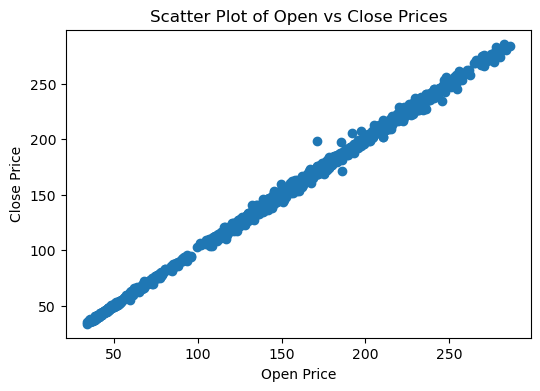

In [296]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.scatter(df["open"], df["close"])

plt.xlabel("Open Price")
plt.ylabel("Close Price")
plt.title("Scatter Plot of Open vs Close Prices")

plt.show()

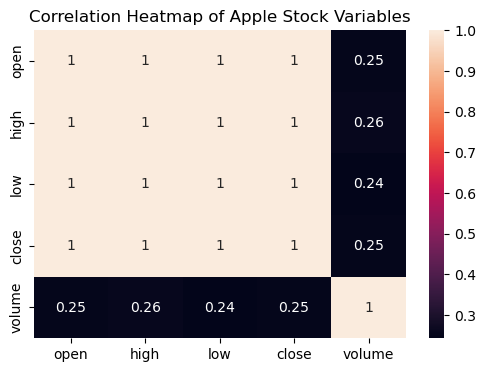

In [297]:
plt.figure(figsize=(6,4))
sns.heatmap(data.corr(), annot=True)
plt.title("Correlation Heatmap of Apple Stock Variables")
plt.show()

### diagnosis:
Multicollinearity can be diagnosed using the **Variance Inflation Factor (VIF)**.

The VIF measures how much the variance of a regression coefficient is inflated due to correlation with other explanatory variables.

The statistic is defined as:

$$
VIF_j = \frac{1}{1 - R_j^2}
$$

where

$$
\begin{aligned}
VIF_j &= \text{Variance Inflation Factor of predictor } X_j \\
R_j^2 &= \text{coefficient of determination when } X_j \\
      &\text{is regressed on the other predictors}
\end{aligned}
$$

The interpretation guidelines are:

| VIF Value | Interpretation |
|-----------|---------------|
| VIF = 1 | No correlation with other predictors |
| 1 < VIF < 5 | Moderate correlation |
| VIF ≥ 5 | Potential multicollinearity |
| VIF ≥ 10 | Severe multicollinearity |

This method is widely used in econometrics because it directly quantifies how strongly explanatory variables depend on each other.

In [299]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = data

vif = pd.DataFrame()

vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values,i) for i in range(X.shape[1])]

vif

,Variable,VIF
0,open,24871.007962
1,high,30094.953776
2,low,32146.475252
3,close,26657.213021
4,volume,4.431043


The results indicate very high VIF values for the variables **open, high, low, and close**.

This is expected because these variables are derived from the same daily trading information and therefore move together in the market.

For example, if the VIF values exceed 10, it suggests severe multicollinearity among these predictors.

This confirms that including all price variables simultaneously in a regression model would create unstable coefficient estimates.

Therefore, the VIF method successfully diagnoses the presence of multicollinearity in the Apple stock dataset.

### damage

Multicollinearity increases the variance of estimated regression coefficients and makes the model unstable.

Small changes in the data may produce large changes in coefficient estimates. In financial applications, this can lead to incorrect identification of factors influencing asset prices or volatility.

### directions

Several methods can be used to reduce multicollinearity:

• Removing highly correlated predictors  
• Applying Principal Component Analysis (PCA)  
• Using Ridge regression  
• Combining correlated variables into a single predictor

### 2. Skewness

### definition

Skewness measures the degree of asymmetry in a probability distribution.

The skewness coefficient is defined as:

$$
Skewness = \frac{E[(X-\mu)^3]}{\sigma^3}
$$

where

$$
\begin{aligned}
\mu &= \text{mean of the distribution} \\
\sigma &= \text{standard deviation} \\
E &= \text{expected value operator}
\end{aligned}
$$

### description

Skewness indicates whether the distribution of financial returns is symmetric or tilted toward extreme positive or negative outcomes.

### demonstration

The skewness of Apple stock returns is examined using the calculated daily returns from the dataset.

In [307]:
df["returns"].describe()

count    2010.000000
mean        0.001137
std         0.019397
min        -0.128648
25%        -0.007919
50%         0.001182
75%         0.011060
max         0.153286
Name: returns, dtype: float64

### diagram

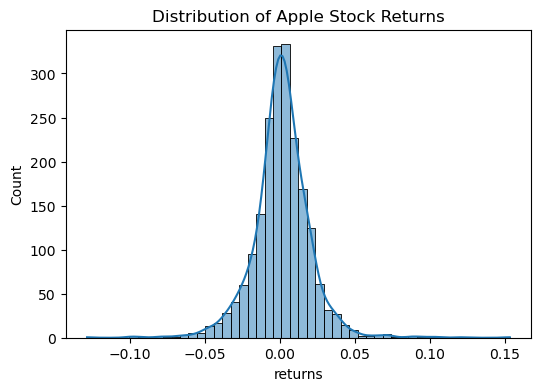

In [309]:
plt.figure(figsize=(6,4))

sns.histplot(df["returns"], bins=50, kde=True)

plt.title("Distribution of Apple Stock Returns")

plt.show()

### diagnosis

In [311]:
df["returns"].skew()

0.1551957762486888

Skewness can be diagnosed by computing the skewness statistic of the return distribution.

A skewness value close to zero indicates a symmetric distribution. Positive skewness suggests a long right tail, while negative skewness indicates a long left tail.

In financial markets, negative skewness often indicates a higher probability of large negative returns.

### damage
If skewness is ignored, risk models may underestimate the likelihood of extreme market movements. This can lead to inaccurate value-at-risk estimates and poor risk management decisions.

### directions
Skewness can be reduced by:

• Applying log transformations  
• Using robust statistical models  
• Applying quantile regression methods

 ### 3. SENSITIVITY TO OUTLIERS

### definition :
Outliers are extreme observations that deviate significantly from the rest of the dataset.

An observation may be considered an outlier if

$$
|X_i - \mu| > 3\sigma
$$

where

$$
\begin{aligned}
X_i &= \text{observed value} \\
\mu &= \text{mean of the distribution} \\
\sigma &= \text{standard deviation}
\end{aligned}
$$

### description
Outliers represent extreme market movements that may distort statistical models and affect parameter estimation.

### demonstration 

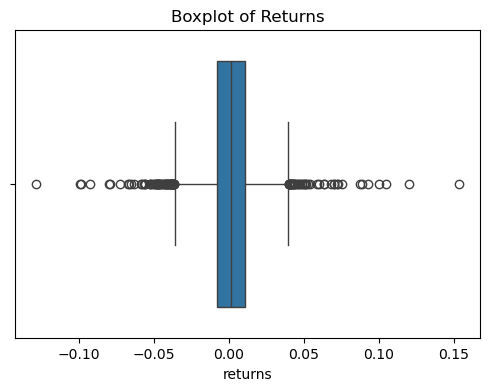

In [319]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["returns"])
plt.title("Boxplot of Returns")
plt.show()

### digrams

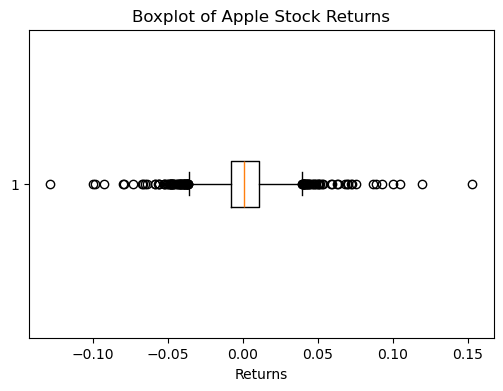

In [321]:
plt.figure(figsize=(6,4))

plt.boxplot(df["returns"], vert=False)

plt.title("Boxplot of Apple Stock Returns")

plt.xlabel("Returns")

plt.show()

The boxplot highlights extreme values in the distribution of returns.  
These points represent potential outliers, which correspond to unusually large positive or negative daily returns in the stock market.

### diagnosis

In [324]:
Q1 = df["returns"].quantile(0.25)
Q3 = df["returns"].quantile(0.75)

IQR = Q3 - Q1

outliers = df[(df["returns"] < Q1 - 1.5*IQR) | (df["returns"] > Q3 + 1.5*IQR)]

len(outliers)

107


Outliers can be detected using the **Interquartile Range (IQR) method**.

The IQR measures the spread of the middle 50% of the data.

$$
IQR = Q_3 - Q_1
$$

An observation is classified as an outlier if it lies outside the interval:

$$
[Q_1 - 1.5(IQR), \; Q_3 + 1.5(IQR)]
$$

where

$$
\begin{aligned}
Q_1 &= \text{first quartile (25th percentile)} \\
Q_3 &= \text{third quartile (75th percentile)} \\
IQR &= \text{interquartile range}
\end{aligned}
$$

This method is widely used because it does not assume that the data follows a normal distribution.  
Since financial return data often contains extreme movements, the IQR method is particularly appropriate for detecting outliers.

### damage :
Outliers may distort regression coefficients and increase volatility estimates, leading to incorrect trading and hedging decisions.



### direction   : 
Methods to reduce outlier effects:
-Winsorization
-Robust regression
-Data transformation

4. ### Overfitting 

### definition
Overfitting occurs when a model captures noise rather than the underlying relationship in the data.

This typically occurs when

$$
Training\ Error \ll Testing\ Error
$$


### description:
Overfitting occurs when a model is excessively complex and fits the training data too closely, reducing its ability to generalize to new data.

### demonstration :

Overfitting can be demonstrated by comparing the performance of a model on training data and unseen testing data.

When a model is overly complex, it fits the training data extremely well but performs poorly on new data.

To illustrate this, the dataset is divided into training and testing sets, and a high-degree polynomial regression model is fitted.

In [332]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

X = np.arange(len(df)).reshape(-1,1)
y = df["close"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=0)

poly = PolynomialFeatures(degree=8)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model = LinearRegression()

model.fit(X_train_poly,y_train)

train_pred = model.predict(X_train_poly)
test_pred = model.predict(X_test_poly)

train_error = mean_squared_error(y_train,train_pred)
test_error = mean_squared_error(y_test,test_pred)

train_error, test_error

(359.57393158946076, 352.244278694075)

The training error is typically much smaller than the testing error.

This large difference indicates that the model fits the training data very well but performs poorly on unseen data.  
Such behavior is a clear indication of overfitting.

### diagram :
A graphical illustration helps demonstrate how an overly complex model may follow noise in the data instead of the true underlying trend.

In the figure below, a high-degree polynomial regression is fitted to the stock price data.

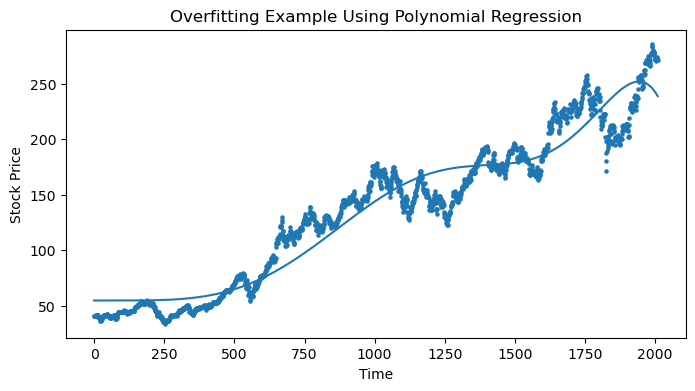

In [335]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import numpy as np

X = np.arange(len(df)).reshape(-1,1)

y = df["close"]

poly = PolynomialFeatures(degree=8)

X_poly = poly.fit_transform(X)

model = LinearRegression()

model.fit(X_poly,y)

pred = model.predict(X_poly)

plt.figure(figsize=(8,4))

plt.scatter(X,y,s=5)

plt.plot(X,pred)

plt.xlabel("Time")

plt.ylabel("Stock Price")

plt.title("Overfitting Example Using Polynomial Regression")

plt.show()

### diagnosis :
Overfitting can be diagnosed by comparing model performance on training data and unseen data.

When a model fits the training data extremely well but performs poorly on new data, it suggests that the model has captured noise rather than the underlying relationship.

### damage :
Overfitting leads to unreliable predictions and trading strategies that perform poorly in real financial markets.

### direction :
Overfitting can be prevented through:

• Cross-validation  
• Regularization techniques such as Lasso and Ridge  
• Reducing model complexity